In [13]:
import cns
import cns.data_utils as cdu
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
samples_df, cns_df = cdu.main_load("3MB")
cns_df = cns.add_total_cn(cns_df)

In [15]:
lusc_group_df = cns.group_samples(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC")))
chr3_group_df = cns.only_aut(lusc_group_df).query("chrom == 'chr3'")
chr3_group_df["cum_mid"] = cns.calc_cum_mid(chr3_group_df)
chr3_group_df["is_count"] = (chr3_group_df["start"] - chr3_group_df["end"].shift(1) == 0) & (chr3_group_df["end"] - chr3_group_df["start"].shift(-1) == 0)
chr3_group_df.head()

,chrom,start,end,name,major_cn,minor_cn,total_cn,sample_id,cum_mid,is_count
518,chr3,0,3016828,chr3_0_0,1.858404,0.137451,1.995855,grouped,493958408,False
519,chr3,3016828,6033657,chr3_0_1,1.866199,0.137101,2.003300,grouped,496975236,True
520,chr3,6033657,9050485,chr3_0_2,1.874999,0.135743,2.010742,grouped,499992065,True
521,chr3,9050485,12067314,chr3_0_3,1.866560,0.133706,2.000266,grouped,503008893,True
522,chr3,12067314,15084142,chr3_0_4,1.850256,0.130281,1.980537,grouped,506025722,True


In [35]:
def calc_angles(cns_df, cn_col, norm = 1):
    if (len(cns_df) < 2):
        return np.zeros(len(cns_df))
    starts = cns_df["start"].values
    ends = cns_df["end"].values
    vals = (cns_df[cn_col]).values
    mids = (starts + (ends - starts) // 2)
    slopes = np.diff(vals) / np.diff(mids) * norm    
    slopes_vec = np.vectorize(cns.calculate_signed_angle)
    angles = slopes_vec(slopes[1:], slopes[:-1])
    angles = np.insert(angles, 0, 0)
    angles = np.append(angles, 0)
    return angles

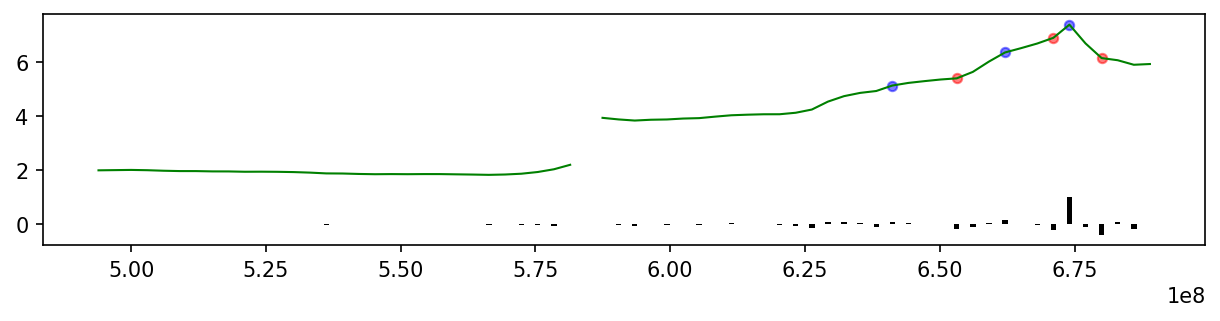

In [36]:
is_consecutive = chr3_group_df["start"] - chr3_group_df["end"].shift(1) != 0

# plot consecutive segments
for i, group_df in chr3_group_df.groupby(is_consecutive.cumsum()):
    # calculate gaussian smoothing of total_cn
    chr3_group_df.loc[group_df.index, "angles"] = calc_angles(group_df, "total_cn", norm=1000000) 
    
fig, ax = plt.subplots(figsize=(10, 2), dpi=150)
feature = "angles"
val_count = 3
sorted_pos = np.argsort(chr3_group_df[feature])
# indices of top 5 values
top_vals = sorted_pos[:val_count]
bot_vals = sorted_pos[-val_count:]

cns.plot_lines(ax, chr3_group_df, cn_column="total_cn")
# bar plot con_der
ax.bar(chr3_group_df["cum_mid"], chr3_group_df[feature] / chr3_group_df[feature].max(), width=1000000, color="black")
# cns.plot_lines(ax, chr3_group_df, cn_column="total_cn_smooth", color="black")

ax.scatter(chr3_group_df["cum_mid"].iloc[top_vals], chr3_group_df["total_cn"].iloc[top_vals], color='red', alpha=0.5, s=20)
ax.scatter(chr3_group_df["cum_mid"].iloc[bot_vals], chr3_group_df["total_cn"].iloc[bot_vals], color='blue', alpha=0.5, s=20)

In [72]:
cos_list = cdu.load_COSMIC()["chr3"]

In [85]:
i_seg = 0
scores = []

for i_gene, gene in enumerate(cos_list):
	score = 0
	total_cn = 0
	g_start = gene[0]
	g_end = gene[1]
	gene_len = gene[1] - gene[0]
	
	while chr3_group_df.iloc[i_seg]["end"] <= g_start:
		i_seg += 1
		if i_seg >= len(chr3_group_df) - 1:
			break
	
	if i_seg >= len(chr3_group_df) - 1:
		break
	while chr3_group_df.iloc[i_seg]["start"] <= g_end:
		seg = chr3_group_df.iloc[i_seg]
		overlap = min(g_end, seg["end"]) - max(g_start, seg["start"])
		score += overlap / gene_len * chr3_group_df["angles"].iloc[i_seg] 
		total_cn += overlap / gene_len * chr3_group_df["total_cn"].iloc[i_seg]
		i_seg += 1
		if i_seg >= len(chr3_group_df) - 1:
			break
	scores.append([gene[0], gene[1], gene[2], score, total_cn])

In [86]:
scores_df = pd.DataFrame(scores, columns=["start", "end", "gene", "score", "total_cn"])
scores_df["abs_score"] = scores_df["score"].abs()
scores_df = scores_df.sort_values("abs_score", ascending=False)
scores_df["chrom"] = "chr3"
scores_df["cum_mid"] = cns.calc_cum_mid(scores_df)
print(scores_df.head(10))

        start        end     gene      score  total_cn  abs_score chrom  \
39  181429713  181432221     SOX2 -15.865854  7.497281  15.865854  chr3   
43  186500993  186507689   EIF4A2  11.746114  6.175335  11.746114  chr3   
46  189349204  189615068     TP63  -6.957301  6.170987   6.957301  chr3   
22   89156673   89531284    EPHA3   4.703833  2.181659   4.703833  chr3   
38  178865901  178957881   PIK3CA  -4.334948  6.937111   4.334948  chr3   
40  185000728  185206885  MAP3K13   3.883482  6.504657   3.883482  chr3   
29  136055076  136471220    STAG1  -2.924850  4.506361   2.924850  chr3   
32  142168076  142297668      ATR  -2.731112  4.859232   2.731112  chr3   
37  176737142  176915261  TBL1XR1   2.495457  6.769403   2.495457  chr3   
33  149235021  149454501    WWTR1  -2.288486  5.204317   2.288486  chr3   

      cum_mid  
39  673880961  
43  678954335  
46  681932130  
22  581793972  
38  671361885  
40  677553800  
29  628713142  
32  634682866  
37  669276195  
33  641794755 

In [120]:
scores_df.head(6)["gene"].values

array(['SOX2', 'EIF4A2', 'TP63', 'EPHA3', 'PIK3CA', 'MAP3K13'],
      dtype=object)

Text(0.5, 1.0, 'Top 2 genes with highest absolute change score on chr3 in LUSC')

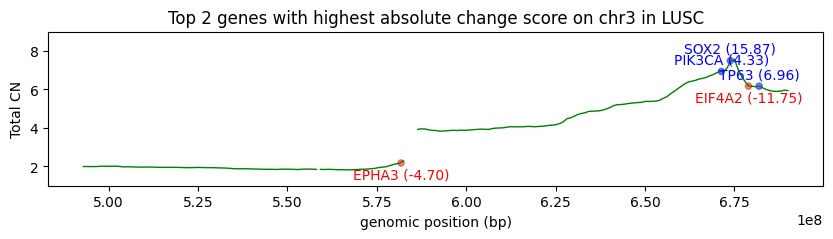

In [118]:
fig, ax = plt.subplots(figsize=(10, 2), dpi=100)
cns.plot_lines(ax, chr3_group_df, cn_column="total_cn")

# scatter plot of top 5 values in scores_df, use red is score is positive, blue if negative
top_count = 5
top_genes = scores_df.head(top_count)
colors = ["red" if score > 0 else "blue" for score in top_genes["score"]]

ax.scatter(top_genes["cum_mid"], top_genes["total_cn"], color=colors, alpha=0.5, s=20)
# add gene names

for i, row in top_genes.iterrows():
	offset = .6 if row["score"] > 0 else -.6
	color = "red" if row["score"] > 0 else "blue"
	ax.text(row["cum_mid"], row["total_cn"] - offset, f'{row["gene"]} ({-row["score"]:.2f})', color=color, fontsize=10, ha="center", va="center")

ax.set_ylim(1, 9)
ax.set_ylabel("Total CN")
ax.set_xlabel("genomic position (bp)")

ax.set_title("Top 2 genes with highest absolute change score on chr3 in LUSC")